In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import griddata
import matplotlib.patheffects as pe
from scipy.spatial import cKDTree

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_AR_from_Q, plot_region_map, add_region_column


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]

In [3]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_ameda = df_ameda[df_ameda.Age>=21]
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
# dic_vert_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/dic_vert_doppio_AMEDA.pkl')
# dic_vert = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/dic_vert_doppio_50m_vert_checked.pkl')


Eddy dataset


In [4]:
df_eddies = add_region_column(
    df_eddies,
    X_grid, Y_grid,
    lon_rho, lat_rho,
    h, mask_rho
)

df_ameda = add_region_column(
    df_ameda,
    X_grid, Y_grid,
    lon_rho, lat_rho,
    h, mask_rho
)


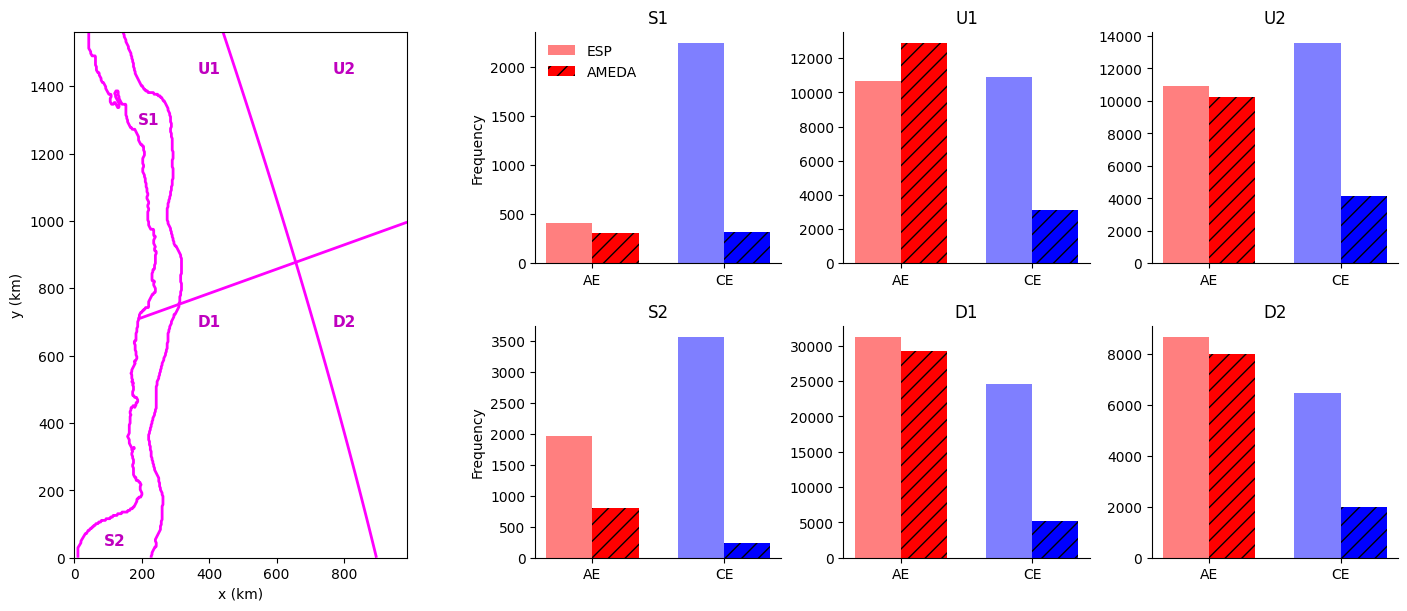

In [5]:
region_order = ['S1', 'U1', 'U2', 'S2', 'D1', 'D2']

fig = plt.figure(figsize=(14, 6), constrained_layout=True)

gs = fig.add_gridspec(
    2, 4,
    width_ratios=[1.8, 1, 1, 1]
)

# --------------------------------------------------
# Region map (left)
# --------------------------------------------------
ax_map = fig.add_subplot(gs[:, 0])

plot_region_map(
    ax_map,
    X_grid,
    Y_grid,
    lon_rho,
    lat_rho,
    h,
    mask_rho,
    levels_lat,
    levels_lon,
    lon_split=157,
    lat_split=-33,
    title=None,
    borders_only=False
)

# --------------------------------------------------
# Bar plots (right)
# --------------------------------------------------
axs = [
    fig.add_subplot(gs[0,1]),
    fig.add_subplot(gs[0,2]),
    fig.add_subplot(gs[0,3]),
    fig.add_subplot(gs[1,1]),
    fig.add_subplot(gs[1,2]),
    fig.add_subplot(gs[1,3]),
]

for k, (ax, region) in enumerate(zip(axs, region_order)):

    esp = (
        df_eddies[df_eddies.Region == region]['Cyc']
        .value_counts()
        .reindex(['AE', 'CE'])
        .fillna(0)
    )

    ameda = (
        df_ameda[df_ameda.Region == region]['Cyc']
        .value_counts()
        .reindex(['AE', 'CE'])
        .fillna(0)
    )

    x = np.arange(2)
    width = 0.35

    ax.bar(
        x - width/2,
        esp.values,
        width,
        color=['red', 'blue'],
        alpha=0.5,
        label='ESP'
    )

    ax.bar(
        x + width/2,
        ameda.values,
        width,
        color=['red', 'blue'],
        hatch='//',
        label='AMEDA'
    )

    ax.set_xticks(x)
    ax.set_xticklabels(['AE', 'CE'])
    ax.set_title(region)
    if k == 0:
        ax.legend(
        ncol=1,
        frameon=False
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axs[0].set_ylabel('Frequency')
axs[3].set_ylabel('Frequency')

plt.show()


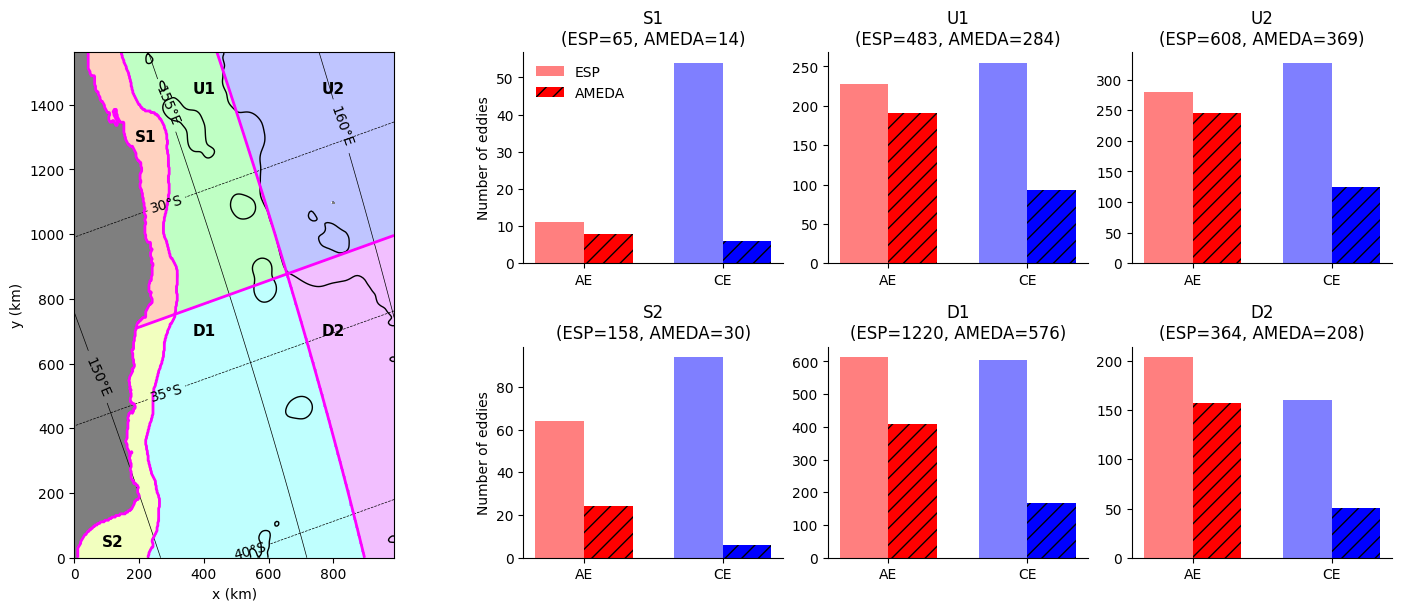

In [7]:
region_order = ['S1', 'U1', 'U2', 'S2', 'D1', 'D2']


def dominant_region_counts(df, threshold=0.5):

    dom_rows = []

    for eddy, dfe in df.dropna(subset=['Region']).groupby('Eddy'):

        frac = dfe['Region'].value_counts(normalize=True)

        dom_region = frac.index[0]
        dom_frac = frac.iloc[0]

        if dom_frac > threshold:
            dom_rows.append({
                'Eddy': eddy,
                'Region': dom_region,
                'Cyc': dfe['Cyc'].iloc[0],
                'Frac': dom_frac
            })

    dom = pd.DataFrame(dom_rows)

    counts = (
        dom.groupby(['Region', 'Cyc'])
        .size()
        .unstack(fill_value=0)
        .reindex(region_order)
        .reindex(columns=['AE', 'CE'], fill_value=0)
    )

    return counts, dom


esp_counts, esp_dom = dominant_region_counts(df_eddies)
ameda_counts, ameda_dom = dominant_region_counts(df_ameda)


# --------------------------------------------------
# Figure
# --------------------------------------------------
fig = plt.figure(figsize=(14, 6), constrained_layout=True)

gs = fig.add_gridspec(
    2, 4,
    width_ratios=[1.8, 1, 1, 1]
)

# --------------------------------------------------
# Region map
# --------------------------------------------------
ax_map = fig.add_subplot(gs[:, 0])

plot_region_map(
    ax_map,
    X_grid,
    Y_grid,
    lon_rho,
    lat_rho,
    h,
    mask_rho,
    levels_lat,
    levels_lon,
    lon_split=157,
    lat_split=-33,
    title=None,
    borders_only=False
)

# --------------------------------------------------
# Bar plots
# --------------------------------------------------
axs = [
    fig.add_subplot(gs[0,1]),
    fig.add_subplot(gs[0,2]),
    fig.add_subplot(gs[0,3]),
    fig.add_subplot(gs[1,1]),
    fig.add_subplot(gs[1,2]),
    fig.add_subplot(gs[1,3]),
]

for k, (ax, region) in enumerate(zip(axs, region_order)):

    esp = esp_counts.loc[region]
    ameda = ameda_counts.loc[region]

    x = np.arange(2)
    width = 0.35

    ax.bar(
        x - width/2,
        esp[['AE', 'CE']],
        width,
        color=['red', 'blue'],
        alpha=0.5,
        label='ESP'
    )

    ax.bar(
        x + width/2,
        ameda[['AE', 'CE']],
        width,
        color=['red', 'blue'],
        hatch='//',
        label='AMEDA'
    )

    ax.set_xticks(x)
    ax.set_xticklabels(['AE', 'CE'])

    ax.set_title(
        f'{region}\n'
        f'(ESP={esp.sum():.0f}, AMEDA={ameda.sum():.0f})'
    )

    if k == 0:
        ax.legend(frameon=False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axs[0].set_ylabel('Number of eddies')
axs[3].set_ylabel('Number of eddies')

plt.show()



In [ ]:
def dominant_region_counts(df, region_order, threshold=0.5):
    dom_rows = []

    for eddy, dfe in df.dropna(subset=['Region']).groupby('Eddy'):
        frac = dfe['Region'].value_counts(normalize=True)
        dom_region = frac.index[0]
        dom_frac = frac.iloc[0]

        if dom_frac > threshold:
            dom_rows.append({
                'Eddy': eddy,
                'Region': dom_region,
                'Cyc': dfe['Cyc'].iloc[0],
                'Frac': dom_frac
            })

    dom = pd.DataFrame(dom_rows)

    if dom.empty:
        return pd.DataFrame(0, index=region_order, columns=['AE', 'CE']), dom

    counts = (
        dom.groupby(['Region', 'Cyc'])
        .size()
        .unstack(fill_value=0)
        .reindex(region_order)
        .reindex(columns=['AE', 'CE'], fill_value=0)
    )

    return counts, dom


def eddy_day_counts(df, region_order):
    return (
        df.dropna(subset=['Region'])
        .groupby(['Region', 'Cyc'])
        .size()
        .unstack(fill_value=0)
        .reindex(region_order)
        .reindex(columns=['AE', 'CE'], fill_value=0)
    )


region_order = ['S1', 'U1', 'U2', 'S2', 'D1', 'D2']

esp_eddy_counts, esp_dom = dominant_region_counts(df_eddies, region_order)
ameda_eddy_counts, ameda_dom = dominant_region_counts(df_ameda, region_order)

esp_day_counts = eddy_day_counts(df_eddies, region_order)
ameda_day_counts = eddy_day_counts(df_ameda, region_order)


In [ ]:
fig = plt.figure(figsize=(14, 6), constrained_layout=True)

gs = fig.add_gridspec(
    2, 4,
    width_ratios=[1.8, 1, 1, 1]
)

# use your existing map code here
ax_map = fig.add_subplot(gs[:, 0])
plot_region_map(
    ax_map,
    X_grid,
    Y_grid,
    lon_rho,
    lat_rho,
    h,
    mask_rho,
    bin_grid,
    region_mask_grid,
    levels_lat,
    levels_lon,
    lon_split=lon_split,
    lat_split=lat_split,
)

# --------------------------------------------------
# Compact 1×2 panels for each region
# --------------------------------------------------

region_gs = gs[:, 1:].subgridspec(
    2, 3,
    hspace=0.35,
    wspace=0.25
)

for k, region in enumerate(region_order):

    row = k // 3
    col = k % 3

    inner = region_gs[row, col].subgridspec(
        1, 2,
        width_ratios=[1, 1],
        wspace=0.05
    )

    axE = fig.add_subplot(inner[0, 0])  # eddies
    axD = fig.add_subplot(inner[0, 1])  # eddy-days

    x = np.arange(2)
    width = 0.35

    # ==================================================
    # Number of eddies
    # ==================================================
    axE.bar(
        x - width/2,
        esp_eddy_counts.loc[region, ['AE', 'CE']],
        width,
        color=['red', 'blue'],
        alpha=0.5,
        label='ESP'
    )

    axE.bar(
        x + width/2,
        ameda_eddy_counts.loc[region, ['AE', 'CE']],
        width,
        color=['red', 'blue'],
        hatch='//',
        label='AMEDA'
    )

    axE.set_xticks(x)
    axE.set_xticklabels(['AE', 'CE'])
    axE.set_title(region)

    if col == 0:
        axE.set_ylabel('No.\neddies')

    axE.spines['top'].set_visible(False)
    axE.spines['right'].set_visible(False)

    # ==================================================
    # Number of eddy-days
    # ==================================================
    axD.bar(
        x - width/2,
        esp_day_counts.loc[region, ['AE', 'CE']],
        width,
        color=['red', 'blue'],
        alpha=0.5
    )

    axD.bar(
        x + width/2,
        ameda_day_counts.loc[region, ['AE', 'CE']],
        width,
        color=['red', 'blue'],
        hatch='//'
    )

    axD.set_xticks(x)
    axD.set_xticklabels(['AE', 'CE'])

    if col == 2:
        axD.set_ylabel('No.\neddy-days')

    axD.spines['top'].set_visible(False)
    axD.spines['right'].set_visible(False)

    # only show y tick labels on outer axes
    if col > 0:
        axE.set_yticklabels([])

    if col < 2:
        axD.set_yticklabels([])

    if k == 0:
        axE.legend(frameon=False)

# optional column titles
fig.text(0.52, 0.98, 'Dominant-region eddies (>50% lifetime)',
         ha='center', va='top', fontsize=12)

fig.text(0.79, 0.98, 'Total eddy-days',
         ha='center', va='top', fontsize=12)

plt.show()


Things to compare
1. max r
2. max tangential velocity
3. vorticity
4. area

In [ ]:
df_phys_geom = df_ameda[['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'xc', 'yc', 'w',
       'ke', 'velmax', 'rmax', 'Age', 'Date', 'fname', 'shapes1', 'area', 'deta']]

df_phys_geom = df_phys_geom.rename(columns={
                    'lon': 'plon',
                    'lat': 'plat',
                    'xc': 'pxc',
                    'yc': 'pyc',
                    'w': 'pw',
                })

cols = ['xc', 'yc',
    'w', 'Omega0', 'Omega', 'Q',
    'Rc', 'psi0', 'R'
]

out = []

for row in df_phys_geom.itertuples(index=False):

    # try:
    df = dic_vert_ameda[f'Eddy{row.Eddy}'][f'Day{row.Day}']
    if len(df):
        data_top = df.iloc[0][cols]
    else:
        data_top = pd.Series(np.nan, index=cols)

    out.append(data_top)

df_top = pd.DataFrame(out).reset_index(drop=True)

df_phys_geom = pd.concat(
    [df_phys_geom.reset_index(drop=True), df_top],
    axis=1
)

df_phys_geom = df_phys_geom.rename(columns={
                    'xc': 'gxc',
                    'yc': 'gyc',
                    'w': 'gw',
                })

points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
values = np.column_stack([lon_rho.ravel(), lat_rho.ravel()])

df_phys_geom[['glon', 'glat']] = griddata(
    points,
    values,
    (df_phys_geom['gxc'].to_numpy(), df_phys_geom['gyc'].to_numpy()),
    method='linear'
)


In [ ]:
df_phys_geom


In [ ]:
def is_valid_Q(Q):
    return isinstance(Q, np.ndarray) and Q.shape == (2, 2) and np.isfinite(Q).all()

ARs = np.full(len(df_phys_geom), np.nan)

valid = df_phys_geom['Q'].apply(is_valid_Q)

if valid.any():
    Q_stack = np.stack(df_phys_geom.loc[valid, 'Q'].values)
    ARs[valid.values] = compute_AR_from_Q(Q_stack)

df_phys_geom['AR'] = ARs


In [ ]:
# Check AR
# if poor only keep Eddy, Day, Cyc, xc, yc, R
# replace the rest NaN

df_phys_geom_QC = df_phys_geom.copy()

AR_mask = df_phys_geom_QC['AR'] > 5
cols_to_nan = [
    'gw', 'Omega',
    'Q', 'Rc', 'psi0', 'AR'
]
df_phys_geom_QC.loc[AR_mask, cols_to_nan] = np.nan

# Check Omega, Rc, psi0 i.e. poor outer-core fits
poor_outer_fits = (
    (df_phys_geom_QC['Rc'] > 300)
    | (df_phys_geom_QC['Rc'] > 1.75*df_phys_geom_QC['R'])
    | (df_phys_geom_QC['Omega'].abs() > 5e-5)
    # | (df_phys_geom_QC['psi0'].abs() > 300)
)
# replace Omega with Omega0
df_phys_geom_QC.loc[poor_outer_fits, 'Omega'] = (
    df_phys_geom_QC.loc[poor_outer_fits, 'Omega0']
)

# remove poor outer-core parameters
df_phys_geom_QC.loc[poor_outer_fits, ['Rc', 'psi0']] = np.nan

df_phys_geom_QC = df_phys_geom_QC.drop(columns='Omega0')
df_phys_geom_QC


In [ ]:
def compare_phys_geom(
    df,
    xcol,
    ycol,
    cyc_col='Cyc',
    figsize=(5, 5),
    s=1,
    alpha=0.5,
    fit=True,
    one_to_one=True,
    ax=None
):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    colors = {'AE': 'r', 'CE': 'c'}

    for cyc in ['AE', 'CE']:

        dfm = df[df[cyc_col] == cyc]

        x = dfm[xcol].values
        y = dfm[ycol].values

        mask = np.isfinite(x) & np.isfinite(y)

        x = x[mask]
        y = y[mask]

        ax.scatter(
            x,
            y,
            marker='.',
            s=s,
            alpha=alpha,
            color=colors[cyc],
            label=cyc
        )

        if fit and len(x) > 1:

            p = np.polyfit(x, y, 1)

            xf = np.linspace(x.min(), x.max(), 100)

            ax.plot(
                xf,
                np.polyval(p, xf),
                color='m' if cyc=='AE' else 'b', #colors[cyc],
                lw=2,
                label=f"{cyc}: y={p[0]:.2f}x{'+' if p[1] > 0 else '-'}{abs(p[1]):.2f}"
            )

    lims = [
        np.nanmin([ax.get_xlim()[0], ax.get_ylim()[0]]),
        np.nanmax([ax.get_xlim()[1], ax.get_ylim()[1]])
    ]

    if one_to_one:
        ax.plot(lims, lims, 'k--', label='y=x')

    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    ax.set_aspect('equal')

    ax.legend(frameon=False)
    
    return
    

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8))
compare_phys_geom(df_phys_geom_QC, 'Rc', 'rmax', ax = axs[0,0])
axs[0,0].set_xlabel(r'DOPPIO $R_c$')
axs[0,0].set_ylabel(r'AMEDA $R_\text{max}$')
axs[0,0].set_xlim(0, None); axs[0,0].set_ylim(0, None)

compare_phys_geom(df_phys_geom_QC, 'gw', 'pw', ax = axs[0,1])
axs[0,1].set_xlabel(r'DOPPIO vorticity (s$^{-1}$)')
axs[0,1].set_ylabel(r'AMEDA vorticity (s$^{-1}$)')
axs[0,1].ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
axs[0,1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

df_phys_geom_QC['g_core_area'] = np.pi * df_phys_geom_QC.Rc**2 / 2
compare_phys_geom(df_phys_geom_QC, 'g_core_area', 'area', ax = axs[0,2])
axs[0,2].set_xlabel(r'DOPPIO core area (km$^2$)')
axs[0,2].set_ylabel(r'AMEDA closed contour area (km$^2$)')
axs[0,2].set_xlim(0, None); axs[0,2].set_ylim(0, None)
axs[0,2].ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
axs[0,2].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

df_phys_geom_QC['VT_max'] = df_phys_geom_QC.Omega.abs()*(df_phys_geom_QC.Rc*1e3)*np.exp(-.5)/np.sqrt(2)
compare_phys_geom(df_phys_geom_QC, 'VT_max', 'velmax', ax = axs[1,0], one_to_one=True)
axs[1,0].set_xlabel(r'DOPPIO max tangential velocity')
axs[1,0].set_ylabel(r'AMEDA closed streamline max velocity')
axs[1,0].set_xlim(0, None); axs[1,0].set_ylim(0, None)

df_phys_geom_QC['xcyc_diff'] = np.hypot(
    df_phys_geom_QC.gxc - df_phys_geom_QC.pxc,
    df_phys_geom_QC.gyc - df_phys_geom_QC.pyc
)

for cyc, color in zip(['AE', 'CE'], ['r', 'b']):
    axs[1,2].hist(
        df_phys_geom_QC.loc[df_phys_geom_QC.Cyc.eq(cyc), 'xcyc_diff'],
        bins=100,
        alpha=0.5,
        label=cyc,
        color=color
    )

axs[1,2].legend()
axs[1,2].set_xlim(0, None); axs[1,2].set_ylim(0, None)
axs[1,2].set_xlabel('DOPPIO and AMEDA eddy center offset')
axs[1,2].set_ylabel('Frequency')

plt.tight_layout()


1. DOPPIO Rc > AMEDA rmax
2. DOPPIO vort > AMEDA vort

In [ ]:
df_phys_geom_QC.columns


In [ ]:
def plot_geom_vs_phys_examples(
    df,
    lon_rho,
    lat_rho,
    X_grid,
    Y_grid,
    nrows=6,
    ncols=6,
    figsize=(12, 12),
    seed=None
):

    if seed is not None:
        np.random.seed(seed)

    valid_Q = df['Q'].apply(
        lambda Q: isinstance(Q, np.ndarray)
        and Q.shape == (2, 2)
        and np.isfinite(Q).all()
    )

    valid_Rc = np.isfinite(df['Rc']) & (df['Rc'] > 0)

    valid = valid_Q & valid_Rc

    n = nrows * ncols

    idxs = np.random.choice(df.index[valid], n, replace=False)

    points = np.column_stack([lon_rho.ravel(), lat_rho.ravel()])
    values = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        constrained_layout=True
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, idx in zip(axes, idxs):

        data = df.loc[idx]

        color = 'r' if data.Cyc == 'AE' else 'c'

        ax.scatter(data.gxc, data.gyc, marker='x', c='k', s=15)
        ax.scatter(data.pxc, data.pyc, marker='^', c='k', s=15)

        pad = 2.5 * data.rmax

        xg = np.linspace(data.gxc - pad, data.gxc + pad, 200)
        yg = np.linspace(data.gyc - pad, data.gyc + pad, 200)

        Xg, Yg = np.meshgrid(xg, yg)

        dx = Xg - data.gxc
        dy = Yg - data.gyc

        rho2 = (
            data.Q[0,0] * dx**2
            + 2 * data.Q[1,0] * dx * dy
            + data.Q[1,1] * dy**2
        )

        ax.contour(
            Xg,
            Yg,
            rho2,
            levels=[data.Rc**2 / 2],
            colors=color,
            linestyles='-'
        )

        xy = griddata(
            points,
            values,
            data.shapes1.vertices,
            method='linear'
        )

        ax.plot(xy[:, 0], xy[:, 1], color=color, ls='--')

        ax.set_aspect('equal')

        ax.set_xlim(data.gxc - pad, data.gxc + pad)
        ax.set_ylim(data.gyc - pad, data.gyc + pad)

        ax.set_title(
            f'E{data.Eddy} D{data.Day}',
            fontsize=8
        )

    return fig, axes
    

In [ ]:
plot_geom_vs_phys_examples(
    df_phys_geom_QC,
    lon_rho,
    lat_rho,
    X_grid,
    Y_grid
)


In [ ]:
plt.hist(np.hypot(df_phys_geom_QC.pxc - df_phys_geom_QC.gxc, df_phys_geom_QC.pyc - df_phys_geom_QC.gyc), bins=100)


In [ ]:
def day_plot(day, df_eddies, df_ameda, out_core_flag=False, center_flag=False):

    fnumber = 1461 + ((day - 1462) // 30)*30
    fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_{fnumber:05}.nc'
    with nc.Dataset(fname) as ds:
        ocean_time = ds['ocean_time'][:] / 86400
        t = np.where(ocean_time == day)[0][0]
        ut = ds['u_eastward'][t, -1, :, :].T
        vt = ds['v_northward'][t, -1, :, :].T

    df_day = df_eddies.loc[df_eddies.Day.eq(day)].copy()
    df_day_ameda = df_ameda.loc[df_ameda.Day.eq(day)].copy()
    
    cs = np.hypot(ut, vt)

    fig, ax = plt.subplots(figsize=(8, 10))
    im = ax.pcolor(X_grid, Y_grid, cs, shading='nearest', vmin=0, vmax=2.5, cmap='Blues_r')
    fig.colorbar(im, ax=ax, label=r'Current speed (ms$^{-1}$)')

    clrs = np.where(df_day.Cyc.eq('CE'), 'c', 'r')
    ax.scatter(df_day.xc, df_day.yc, c=clrs, edgecolors='k', linewidths=0.8, s=20, zorder=10)

    clrs_ameda = np.where(df_day_ameda.Cyc.eq('CE'), 'c', 'r')
    # ax.scatter(df_day_ameda.xc, df_day_ameda.yc, marker='^', c=clrs_ameda, edgecolors='k', linewidths=0.8, s=30, zorder=10)
    ax.scatter(df_day_ameda.xc, df_day_ameda.yc, marker='x', c=clrs_ameda, linewidths=0.8, s=80, zorder=9)

    for e, xc, yc in zip(df_day_ameda.Eddy, df_day_ameda.xc, df_day_ameda.yc):
        ax.annotate(
            str(e), (xc, yc),
            textcoords='offset points', xytext=(3, -8),
            fontsize=10, color='orange', weight='bold',
            path_effects=[pe.withStroke(linewidth=2, foreground='k')],
            zorder=11
        )

    if center_flag: 
    
        if 'Q' not in df_day.columns:
            df_day['Q'] = list(
                np.stack([
                    np.stack([df_day.q11.values, df_day.q12.values], axis=1),
                    np.stack([df_day.q12.values, df_day.q22.values], axis=1)
                ], axis=1)
            )
    
        for xc, yc, e, Q, Rc, R, cyc in zip(df_day.xc, df_day.yc, df_day.Eddy, df_day.Q, df_day.Rc, df_day.R, df_day.Cyc):
    
            # ----- Where I plot the eddy's maximum tangenital velocity contour -----
            dx_ell, dy_ell = X_grid - xc, Y_grid - yc
            rho2_ell = Q[0,0]*dx_ell**2 + 2*Q[1,0]*dx_ell*dy_ell + Q[1,1]*dy_ell**2 # rho^2
            ax.contour(X_grid, Y_grid, rho2_ell, levels=[Rc**2/2], colors='r' if cyc=='AE' else 'c', linestyles='-')
            if out_core_flag:
                ax.contour(X_grid, Y_grid, rho2_ell, levels=[(1.75*R)**2], linestyles='-', colors='r' if cyc=='AE' else 'c')
            # -----------------------------------------------------------------------
    
            ax.annotate(
                str(e), (xc, yc),
                textcoords='offset points', xytext=(3, 3),
                fontsize=10, color='w', weight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='k')],
                zorder=11
            )

        points = np.column_stack([lon_rho.ravel(), lat_rho.ravel()])
        values = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
        
        for _, data in df_day_ameda.iterrows():
        
            xy = griddata(
                points,
                values,
                (data.shapes1.vertices[:, 0],
                 data.shapes1.vertices[:, 1]),
                method='linear'
            )
        
            ax.plot(
                xy[:, 0],
                xy[:, 1],
                color='r' if data.Cyc == 'AE' else 'c',
                ls='--'
            )

    c1 = ax.contour(X_grid, Y_grid, lat_rho, levels=[-40, -35, -30, -25], colors='k', linewidths=.5)
    ax.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')
    c2 = ax.contour(X_grid, Y_grid, lon_rho, levels=[150, 155, 160], colors='k', linewidths=.5)
    ax.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')
                
    ax.set_title(f'Day {day} | {pd.Timestamp("1990-01-01") + pd.Timedelta(days=day)}')
    ax.set_aspect('equal', adjustable='datalim')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.set_xlim(x_grid.min(), x_grid.max())
    ax.set_ylim(y_grid.min(), y_grid.max())
    

In [ ]:
day_plot(2537, df_eddies, df_ameda, center_flag=True, out_core_flag=False)
         